
# Image Captioning with **Qwen 2.5-VL**




## 1.  Install necessary packages


In [ ]:
!pip install qwen-vl-utils  # Upgrade Qwen-VL utilities

## 2.  Imports

In [ ]:
# ── Standard library ────────────────────────────────────────────
import os          # File‑system helpers (paths, env vars, etc.)
import random      # Lightweight randomness (e.g. sample prompts)
import textwrap    # Nicely format long strings for display
import io          # In‑memory byte streams (e.g. image buffers)
import requests    # Simple HTTP requests for downloading assets

# ── Numerical computing ─────────────────────────────────────────
import numpy as np  # Core array maths (fast, vectorised operations)

# ── Deep‑learning stack ─────────────────────────────────────────
import torch  # Tensor library + GPU acceleration
from transformers import (
    Qwen2_5_VLForConditionalGeneration,  # Multimodal LLM (image+text)
    AutoProcessor,                       # Paired tokenizer/feature‑extractor
)

# ── Imaging & visualisation ─────────────────────────────────────
from PIL import Image                    # Pillow: load/save/manipulate images
import matplotlib.pyplot as plt          # Quick plots in notebooks
import matplotlib.patches as patches     # Bounding‑box overlays, etc.

# ── Project‑specific helpers ────────────────────────────────────
from qwen_vl_utils import process_vision_info  # Post‑process Qwen outputs

# ── Notebook conveniences ──────────────────────────────────────
import IPython.display as ipd             # Inline display (images, audio, HTML)

## 3.  Device & model load

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype="auto",     # automatically uses FP16 on GPU, FP32 on CPU
    device_map="auto"       # dispatches layers to the available device(s)
)
processor = AutoProcessor.from_pretrained(model_id)

print(f"Model loaded on: {model.device}")


## 4.  Fetch or upload an image


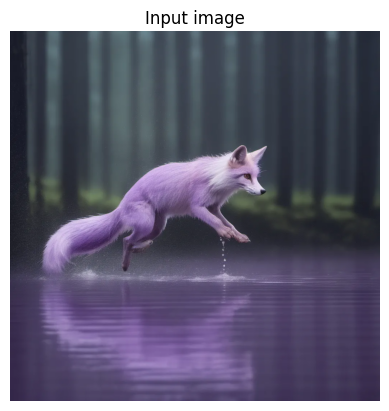

In [ ]:
# url = ""
# img = Image.open(io.BytesIO(requests.get(url, timeout=15).content)).convert("RGB")
img = Image.open("fox.png")

# Display the image
plt.imshow(img)
plt.axis("off")
plt.title("Input image")
plt.show()


## 5.  Build a chat-style prompt
### 5.1 Create a message in JSON format
Qwen VL uses the same multi-turn message format as Qwen-2.5-Chat:
 ```python
 msgs = [
     { "role": "user",
       "content": [
           {"type": "image", "image": img},
           {"type": "text",  "text": "Describe this image."}
       ],
     }
 ]
 ```
The processor turns these messages into plain text (with special tokens) and extracts the visual tensors so the model receives *both* modalities.

In [ ]:
msgs = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Describe this image."}
        ],
    }
]

### 5.2 Apply Chat Template
Every chat model ships with a pattern. The above JSON format needs to be converted to this template and this is done using `apply_chat_template`. It performs three tasks.
1. **Reads the model’s chat template**: Qwen 2.5VL has a chat template that looks like `<|im_start|>{role}\n{content}<|im_end|>`.
2. **Fills in the template with the msgs list**. It loops over each message, swaps in the role (user, assistant, etc.) and the content (text plus special <image> markers), and concatenates the result into one long string.
3. **Adds the “assistant starts talking now” marker** (add_generation_prompt=True). At the end it appends `<|im_start|>assistant`
4. Instruction to NOT tokenize the text because the processor is used to process text and images together, and tokenization will be performed in that step.


In [ ]:
# Build the full textual prompt that Qwen-VL expects
# --------------------------------------------------
# • msgs : list of message dicts (roles + content, including <image> markers)
# • tokenize=False : return a plain string—not token IDs—so we can
#                    combine it with image tensors in the next processor() call
# • add_generation_prompt=True : appends the “assistant is about to speak” marker
#                                (e.g. "<|im_start|>assistant\n"), which tells the
#                                model where its reply should begin.
text_prompt = processor.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)

# For sanity-checking: print the raw prompt string that will be fed to the model
print(text_prompt)


<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>
<|im_start|>assistant



### 5.3 Extract image & video inputs from `msg`

Now, to extract images and videos from `msg` using `process_vision_info` utility. It performs the following tasks
1. Walks through every message,
2. Finds all `"image"` / `"video"` entries,
3. Applies the Qwen-VL visual pre-processing to ensure each image is a PIL.Image (or each video is a list / tensor of frames).
4. Returns two parallel lists/tensors
 - `image_inputs`  → batched image tensors (or [] if none)
 - `video_inputs`  → batched video tensors (or [] if none)

In [ ]:
# Extract vision-modalities from msgs and convert them to model-ready tensors
# --------------------------------------------------------------------------
# • msgs : the same chat-style list you fed to apply_chat_template.
#          Each dict can include items like {"type": "image", "image": img}
#          or {"type": "video", "video": video_clip}.
# • process_vision_info : project utility that
#       1) walks through every message,
#       2) finds all `"image"` / `"video"` entries,
#       3) applies the Qwen-VL visual pre-processing to ensure each
#          image is a PIL.Image (or each video is a list / tensor of frames).
#       4) returns two parallel lists/tensors:
#            – `image_inputs`  → batched image tensors (or [] if none)
#            – `video_inputs`  → batched video tensors (or [] if none)
#   These outputs plug straight into the `processor(...)` call that follows,
#   ensuring the vision data is aligned with the text prompt.
image_inputs, video_inputs = process_vision_info(msgs)


## 6.  Generate the caption

### 6.1 Run inference

In [ ]:
# ── Pack text + vision into model-ready tensors ──────────────────────────────
inputs = processor(
    text=[text_prompt],      # 1-element batch containing the chat prompt string
    images=image_inputs,     # list of raw PIL images (pre-processed inside processor)
    videos=video_inputs,     # list of raw video clips (if any)
    padding=True,            # pad sequences so text/vision tokens line up in a batch
    return_tensors="pt",     # return a dict of PyTorch tensors (input_ids, pixel_values, …)
).to(model.device)           # move every tensor—text & vision—to the model’s GPU/CPU

# ── Run inference (no gradients, pure generation) ───────────────────────────
with torch.no_grad():                     # disable autograd to save memory
    generated_ids = model.generate(       # autoregressive decoding
        **inputs,                         # unpack dict into generate(...)
        max_new_tokens=64                 # cap the response at 64 tokens
    )
print(inputs.input_ids[0])
print(generated_ids)

tensor([151644,   8948,    198,  ..., 151644,  77091,    198], device='cuda:0')
tensor([[151644,   8948,    198,  ...,  16566,     13,    576]],
       device='cuda:0')


### 6.2 Decode output

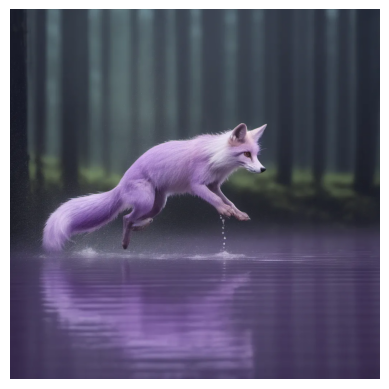

The image depicts a fox with a striking, iridescent purple coat leaping into a
body of water. The fox's fur appears to shimmer with a magical, almost ethereal
quality, reflecting light in various hues. The background features a dense
forest with tall, dark trees, creating a serene and mystical atmosphere. The


In [ ]:
# Extract the newly generated tokens (skip the prompt length)
caption = processor.batch_decode(
    generated_ids[:, inputs.input_ids.shape[-1]:],
    skip_special_tokens=True
)[0]

# Display the image
plt.imshow(img)
plt.axis("off")
plt.show()

# Print caption
width = 80
wrapped_caption = textwrap.fill(caption, width)
print(wrapped_caption)
